In [1]:
# Install required libraries
!pip install ultralytics
!pip install roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 114.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


In [2]:
# Import required libraries
from ultralytics import YOLO
from roboflow import Roboflow
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="XprIetE05kQWU8MWtzFC")
project = rf.workspace("saharsh-kumar-singh").project("brain-tumor-detection-o0ggc-luqlk")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to brain-tumor-detection-1 in yolov8:: 100%|██████████| 1139/1139 [00:00<00:00, 5794.11it/s]


In [4]:
# Load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")


In [6]:
import os

print(os.listdir("/content"))


['.config', 'runs', 'brain-tumor-detection-1', 'yolov8n.pt', 'sample_data']


In [7]:
# Train the model
results = model.train(
    data="/content/brain-tumor-detection-1/data.yaml",
    epochs=10,
    imgsz=640,
    batch=8
)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/brain-tumor-detection-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optim

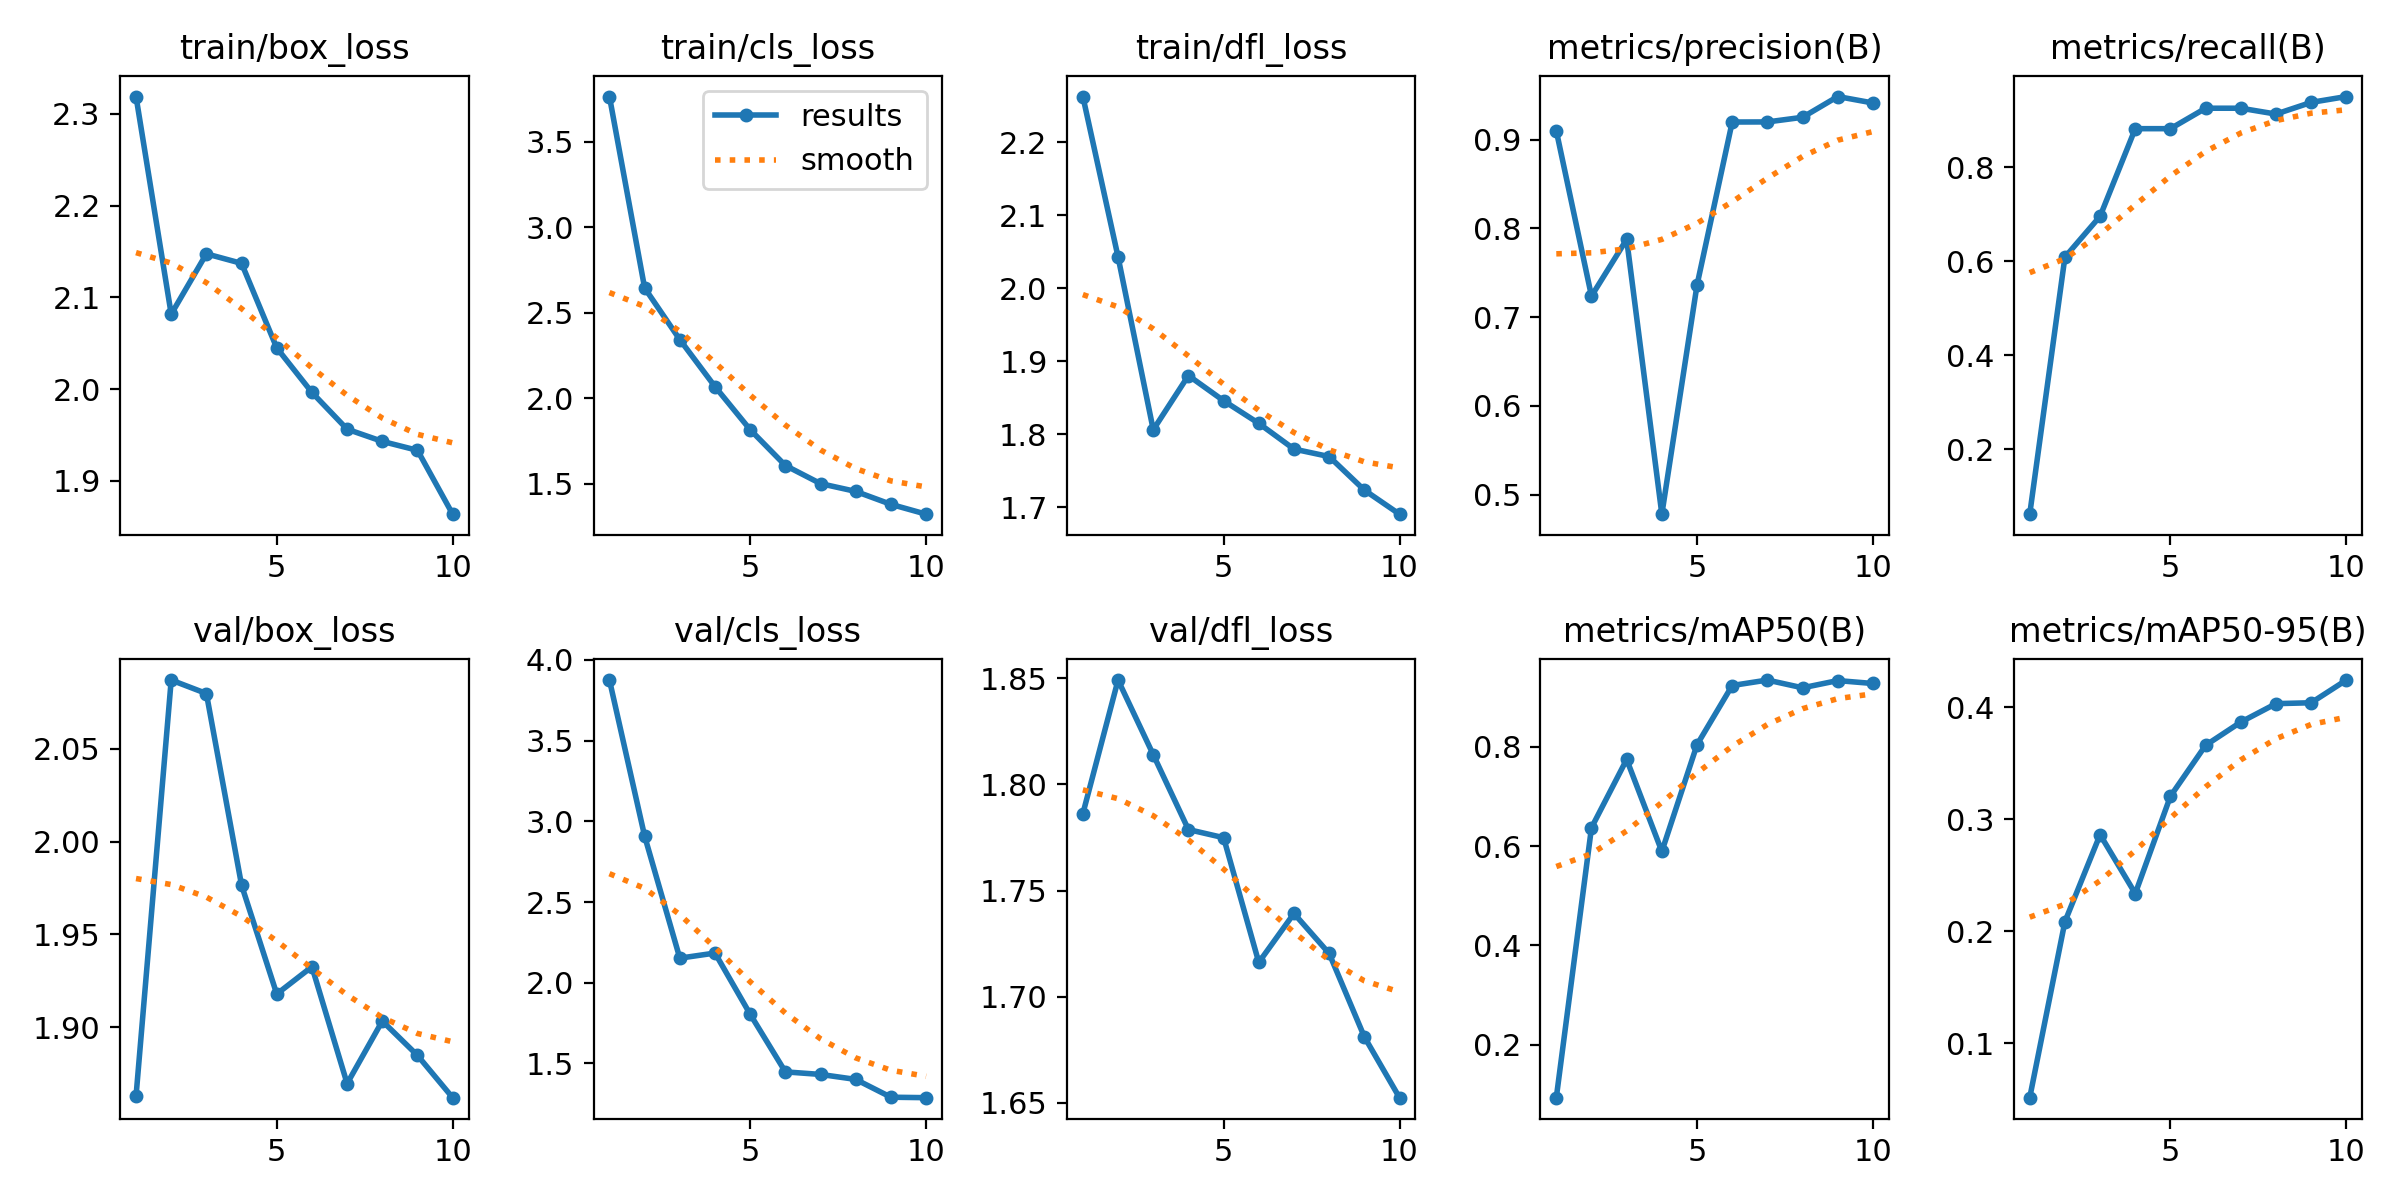

In [8]:
from IPython.display import Image

Image("/content/runs/detect/train-2/results.png", width=900)

In [9]:
import os

print(os.listdir("/content/runs/detect/train-2"))

['results.csv', 'BoxP_curve.png', 'BoxR_curve.png', 'BoxF1_curve.png', 'labels.jpg', 'val_batch1_pred.jpg', 'weights', 'confusion_matrix_normalized.png', 'train_batch1.jpg', 'val_batch2_pred.jpg', 'val_batch0_pred.jpg', 'train_batch2.jpg', 'train_batch0.jpg', 'args.yaml', 'val_batch0_labels.jpg', 'val_batch2_labels.jpg', 'confusion_matrix.png', 'results.png', 'val_batch1_labels.jpg', 'BoxPR_curve.png']


In [10]:
# Load the best trained model
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train-2/weights/best.pt")

In [15]:
# Predict on the test images
model.predict(
    source="/content/brain-tumor-detection-1/test/images",
    save=True,
    conf=0.25
)


image 1/56 /content/brain-tumor-detection-1/test/images/Brain-Tumor-Overview_mp4-0017_jpg.rf.cc8881e0a80e83ae05da6eeb7647bf8c.jpg: 640x640 1 tumor, 355.9ms
image 2/56 /content/brain-tumor-detection-1/test/images/Brain-Tumor-Overview_mp4-0113_jpg.rf.f72a9a895324e46a67e98fef850f17bb.jpg: 640x640 1 tumor, 352.0ms
image 3/56 /content/brain-tumor-detection-1/test/images/Brain-Tumor-Overview_mp4-0125_jpg.rf.8da733a25a0613ac2645c13b853584fb.jpg: 640x640 1 tumor, 800.5ms
image 4/56 /content/brain-tumor-detection-1/test/images/Brain-Tumor-Overview_mp4-0129_jpg.rf.5dcf097b9a9b12429b1c3f31ae3392d4.jpg: 640x640 1 tumor, 422.4ms
image 5/56 /content/brain-tumor-detection-1/test/images/Brain-Tumor-Overview_mp4-0152_jpg.rf.a4d8995d6b8ed64a42f878a5905aba80.jpg: 640x640 1 tumor, 590.9ms
image 6/56 /content/brain-tumor-detection-1/test/images/Brain-Tumor-Overview_mp4-0193_jpg.rf.a3851ec64acaed13d06e398ee5a92254.jpg: 640x640 1 tumor, 549.8ms
image 7/56 /content/brain-tumor-detection-1/test/images/Brain-T

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'tumor'}
 obb: None
 orig_img: array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
    

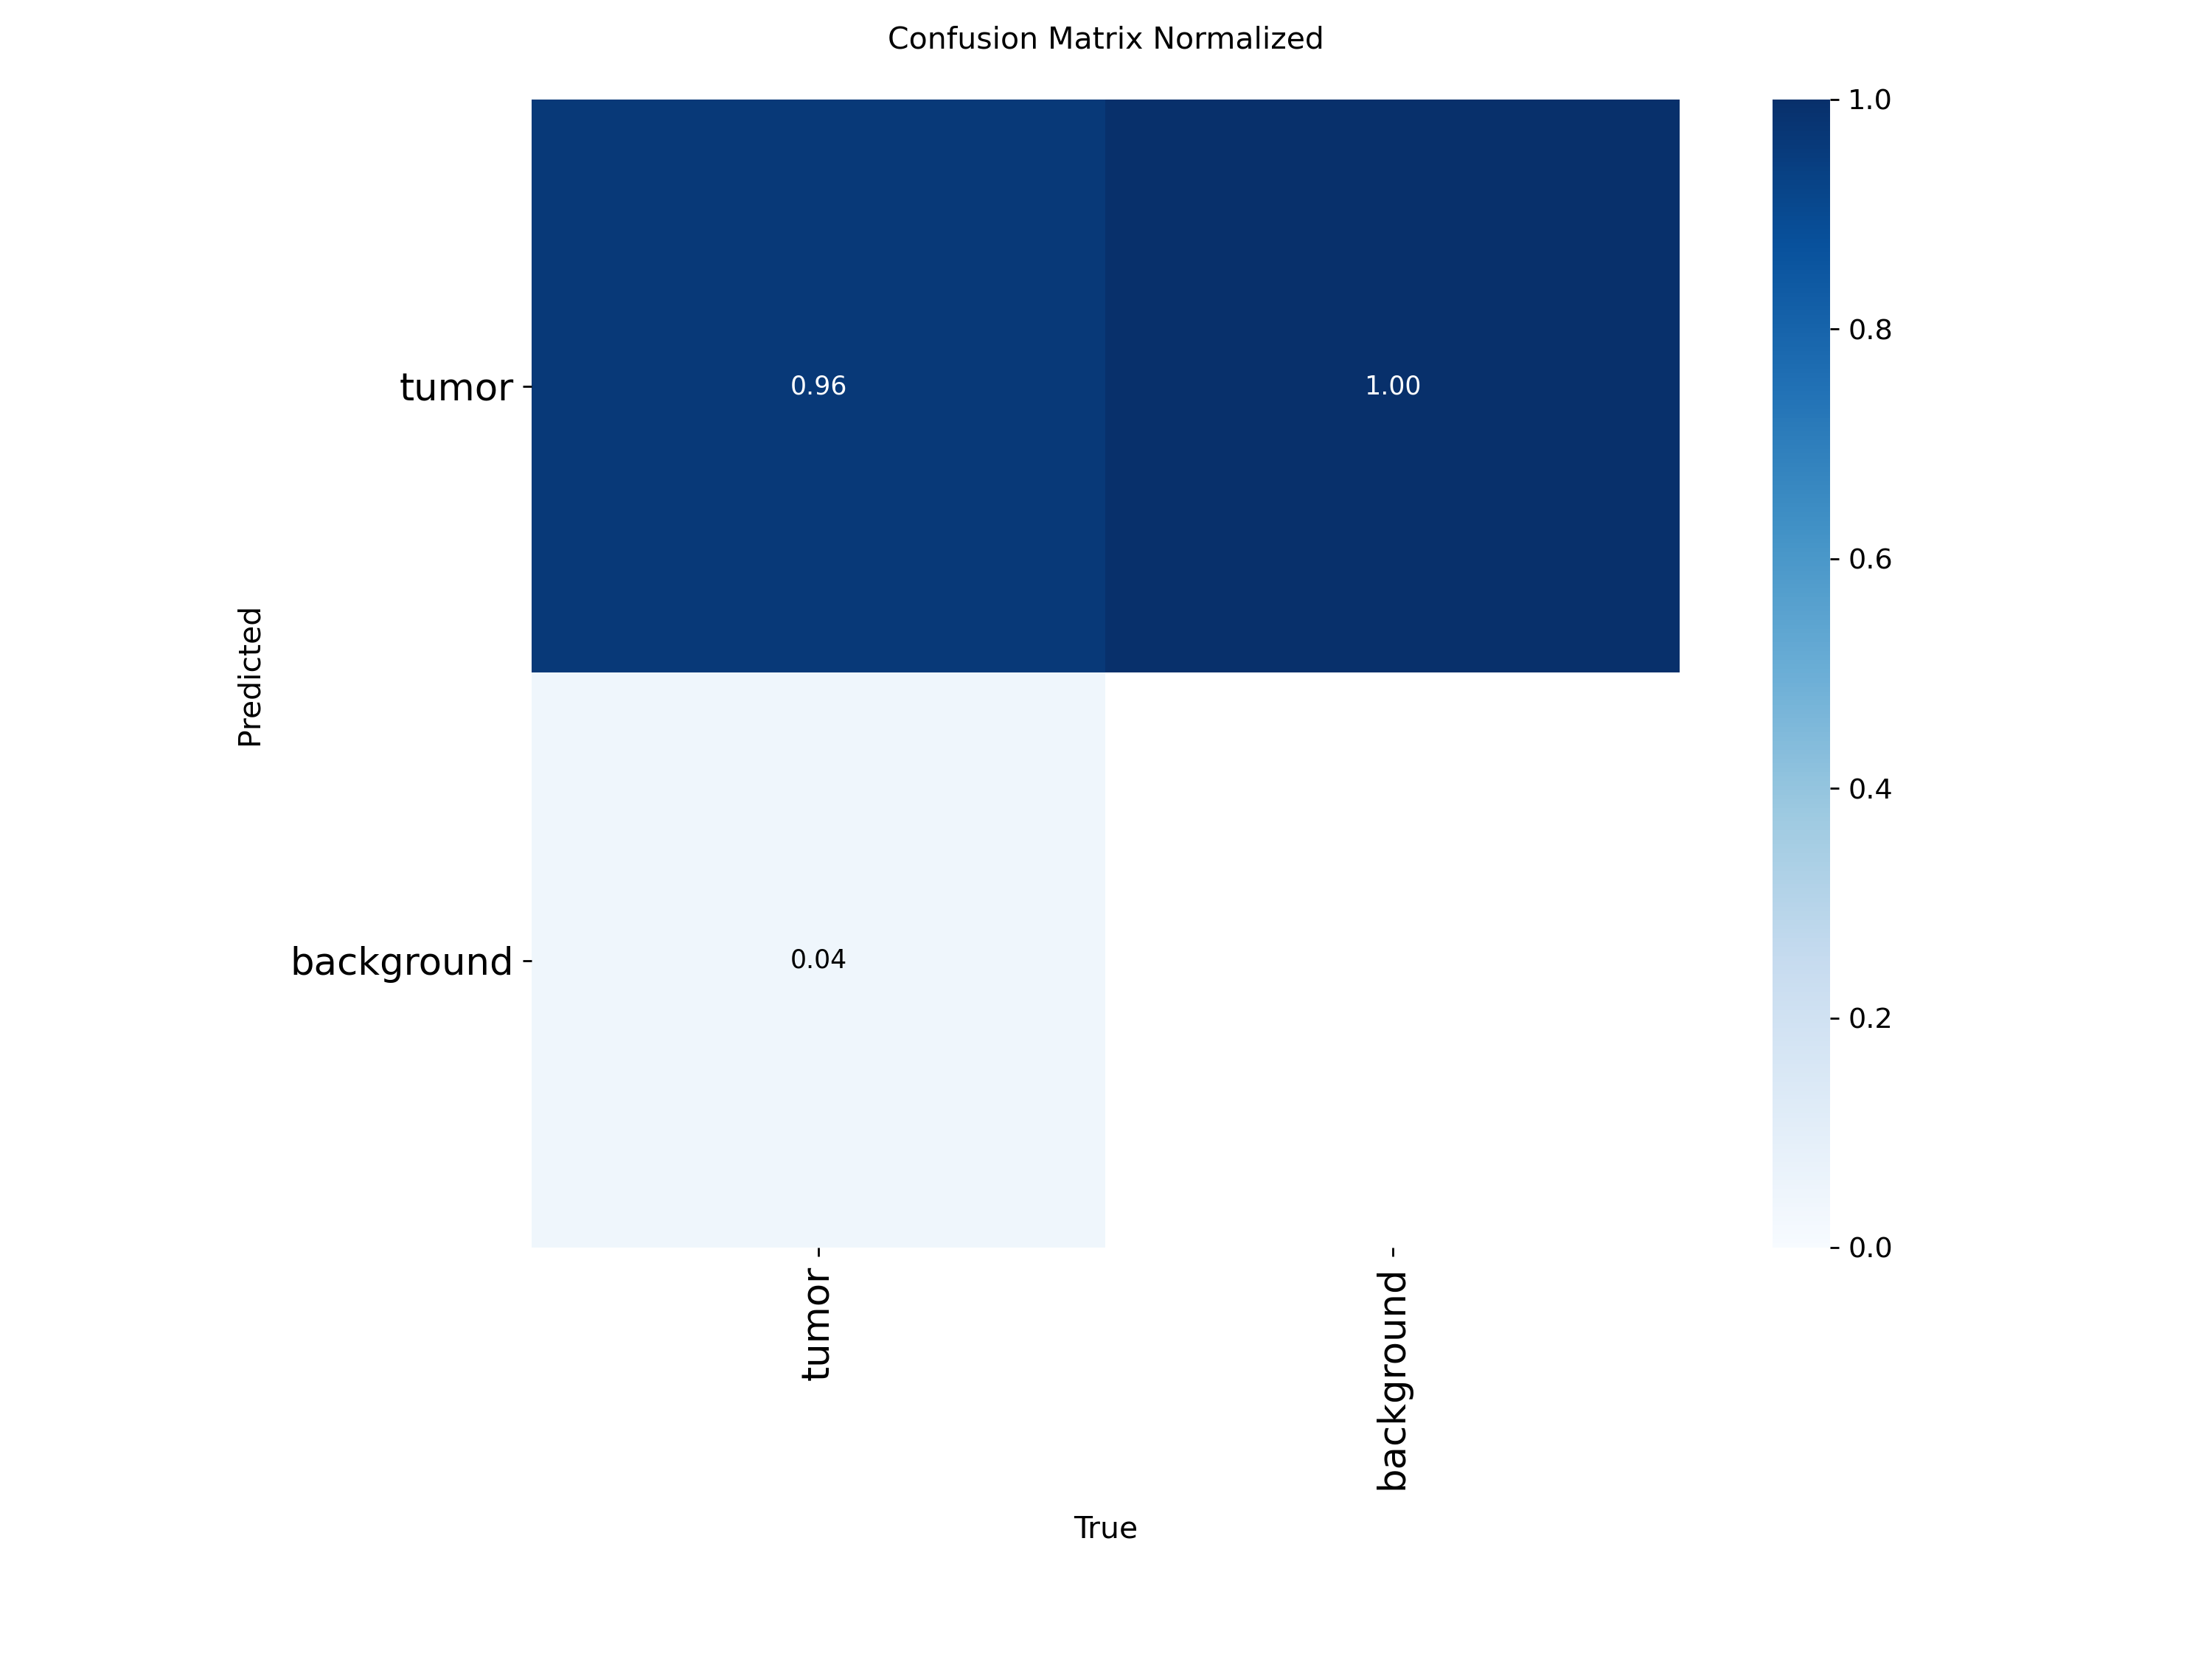

In [17]:
Image("/content/runs/detect/train-2/confusion_matrix.png", width=700)
Image("/content/runs/detect/train-2/confusion_matrix_normalized.png", width=700)

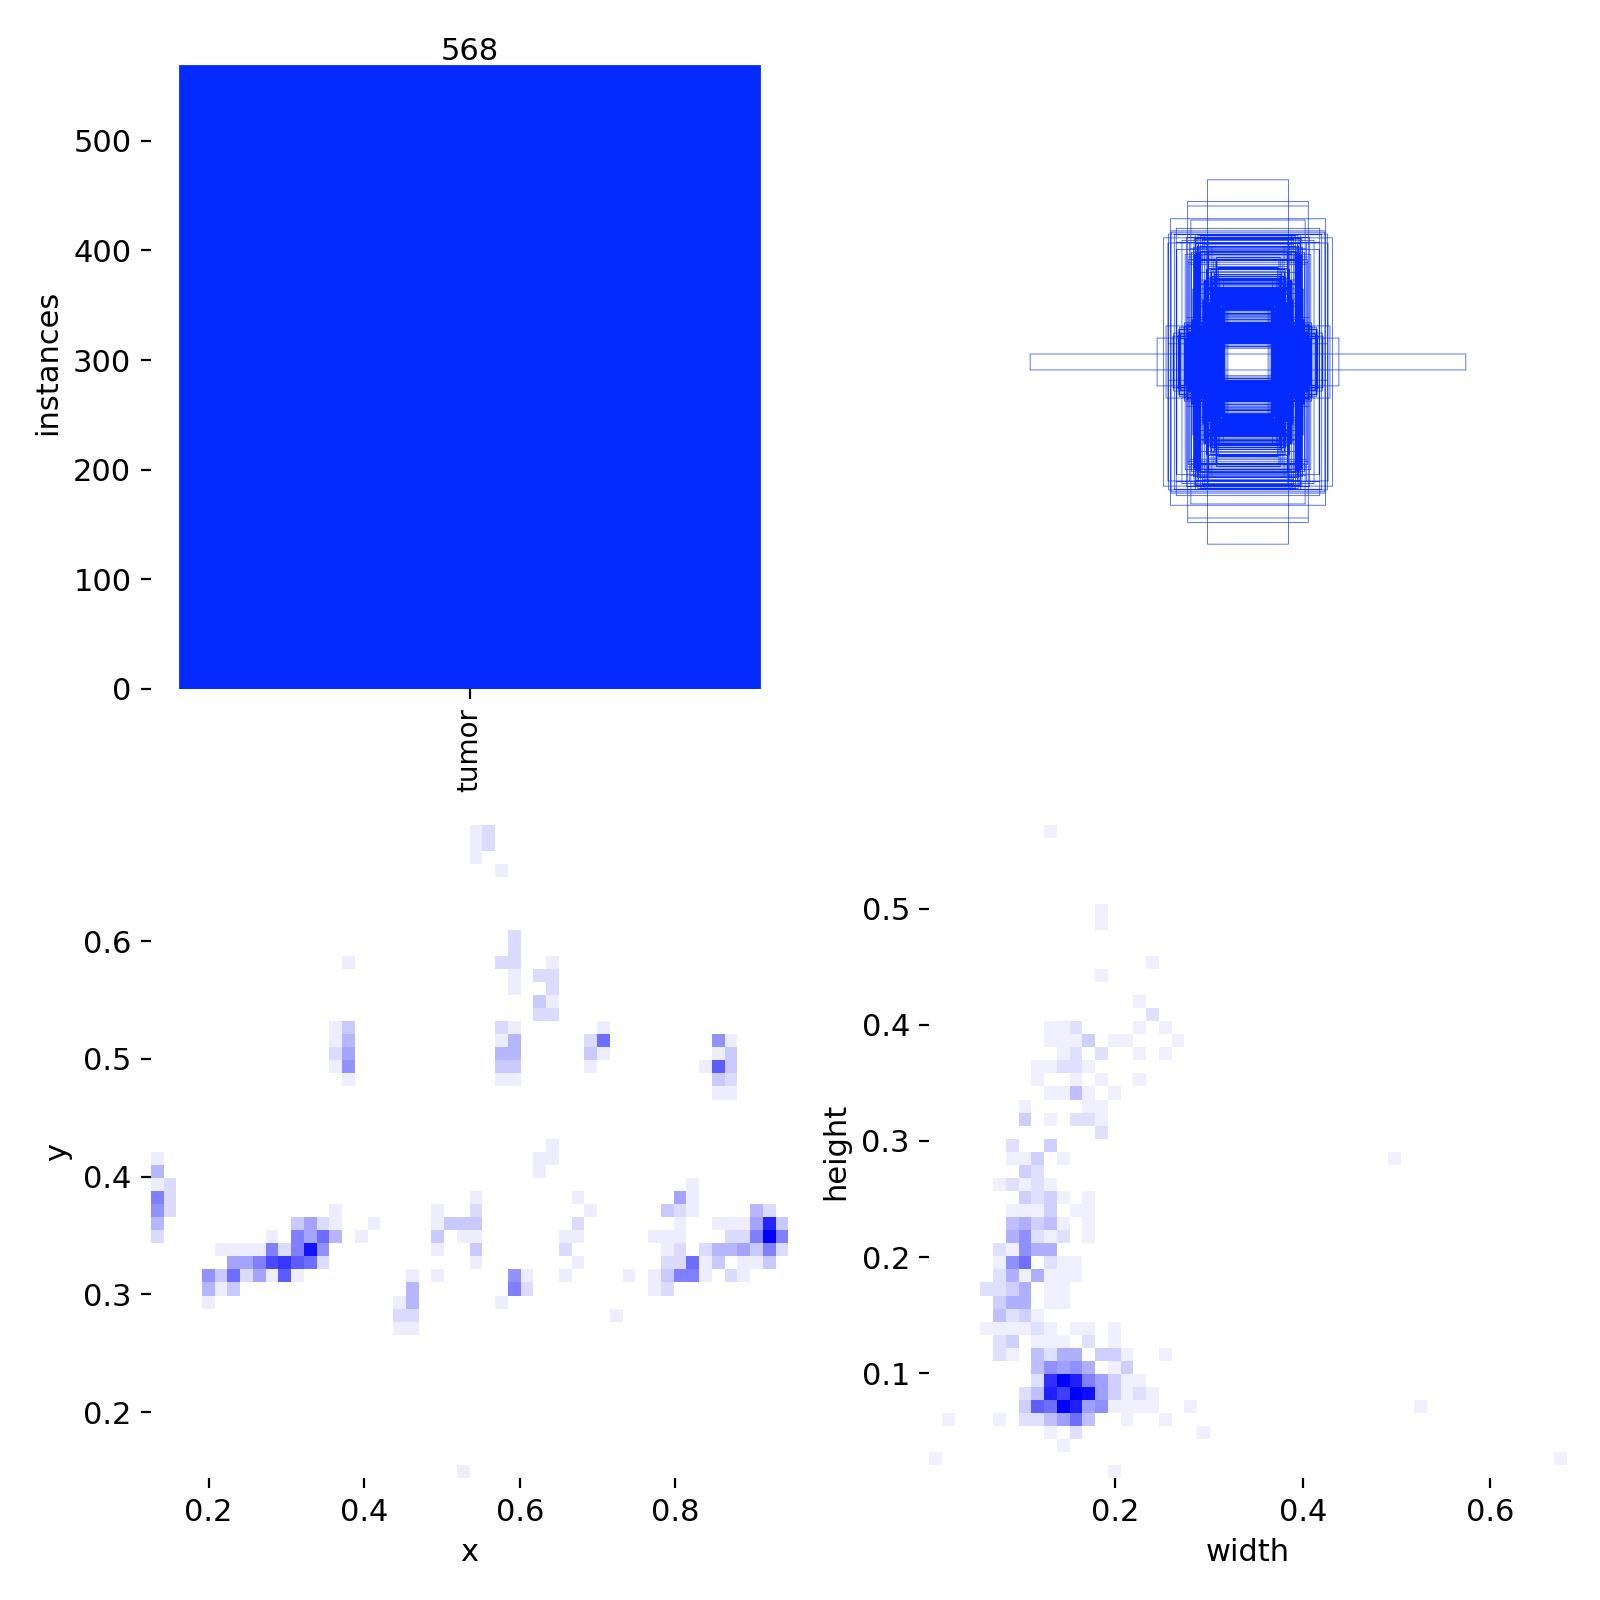

In [18]:
Image("/content/runs/detect/train-2/labels.jpg", width=700)


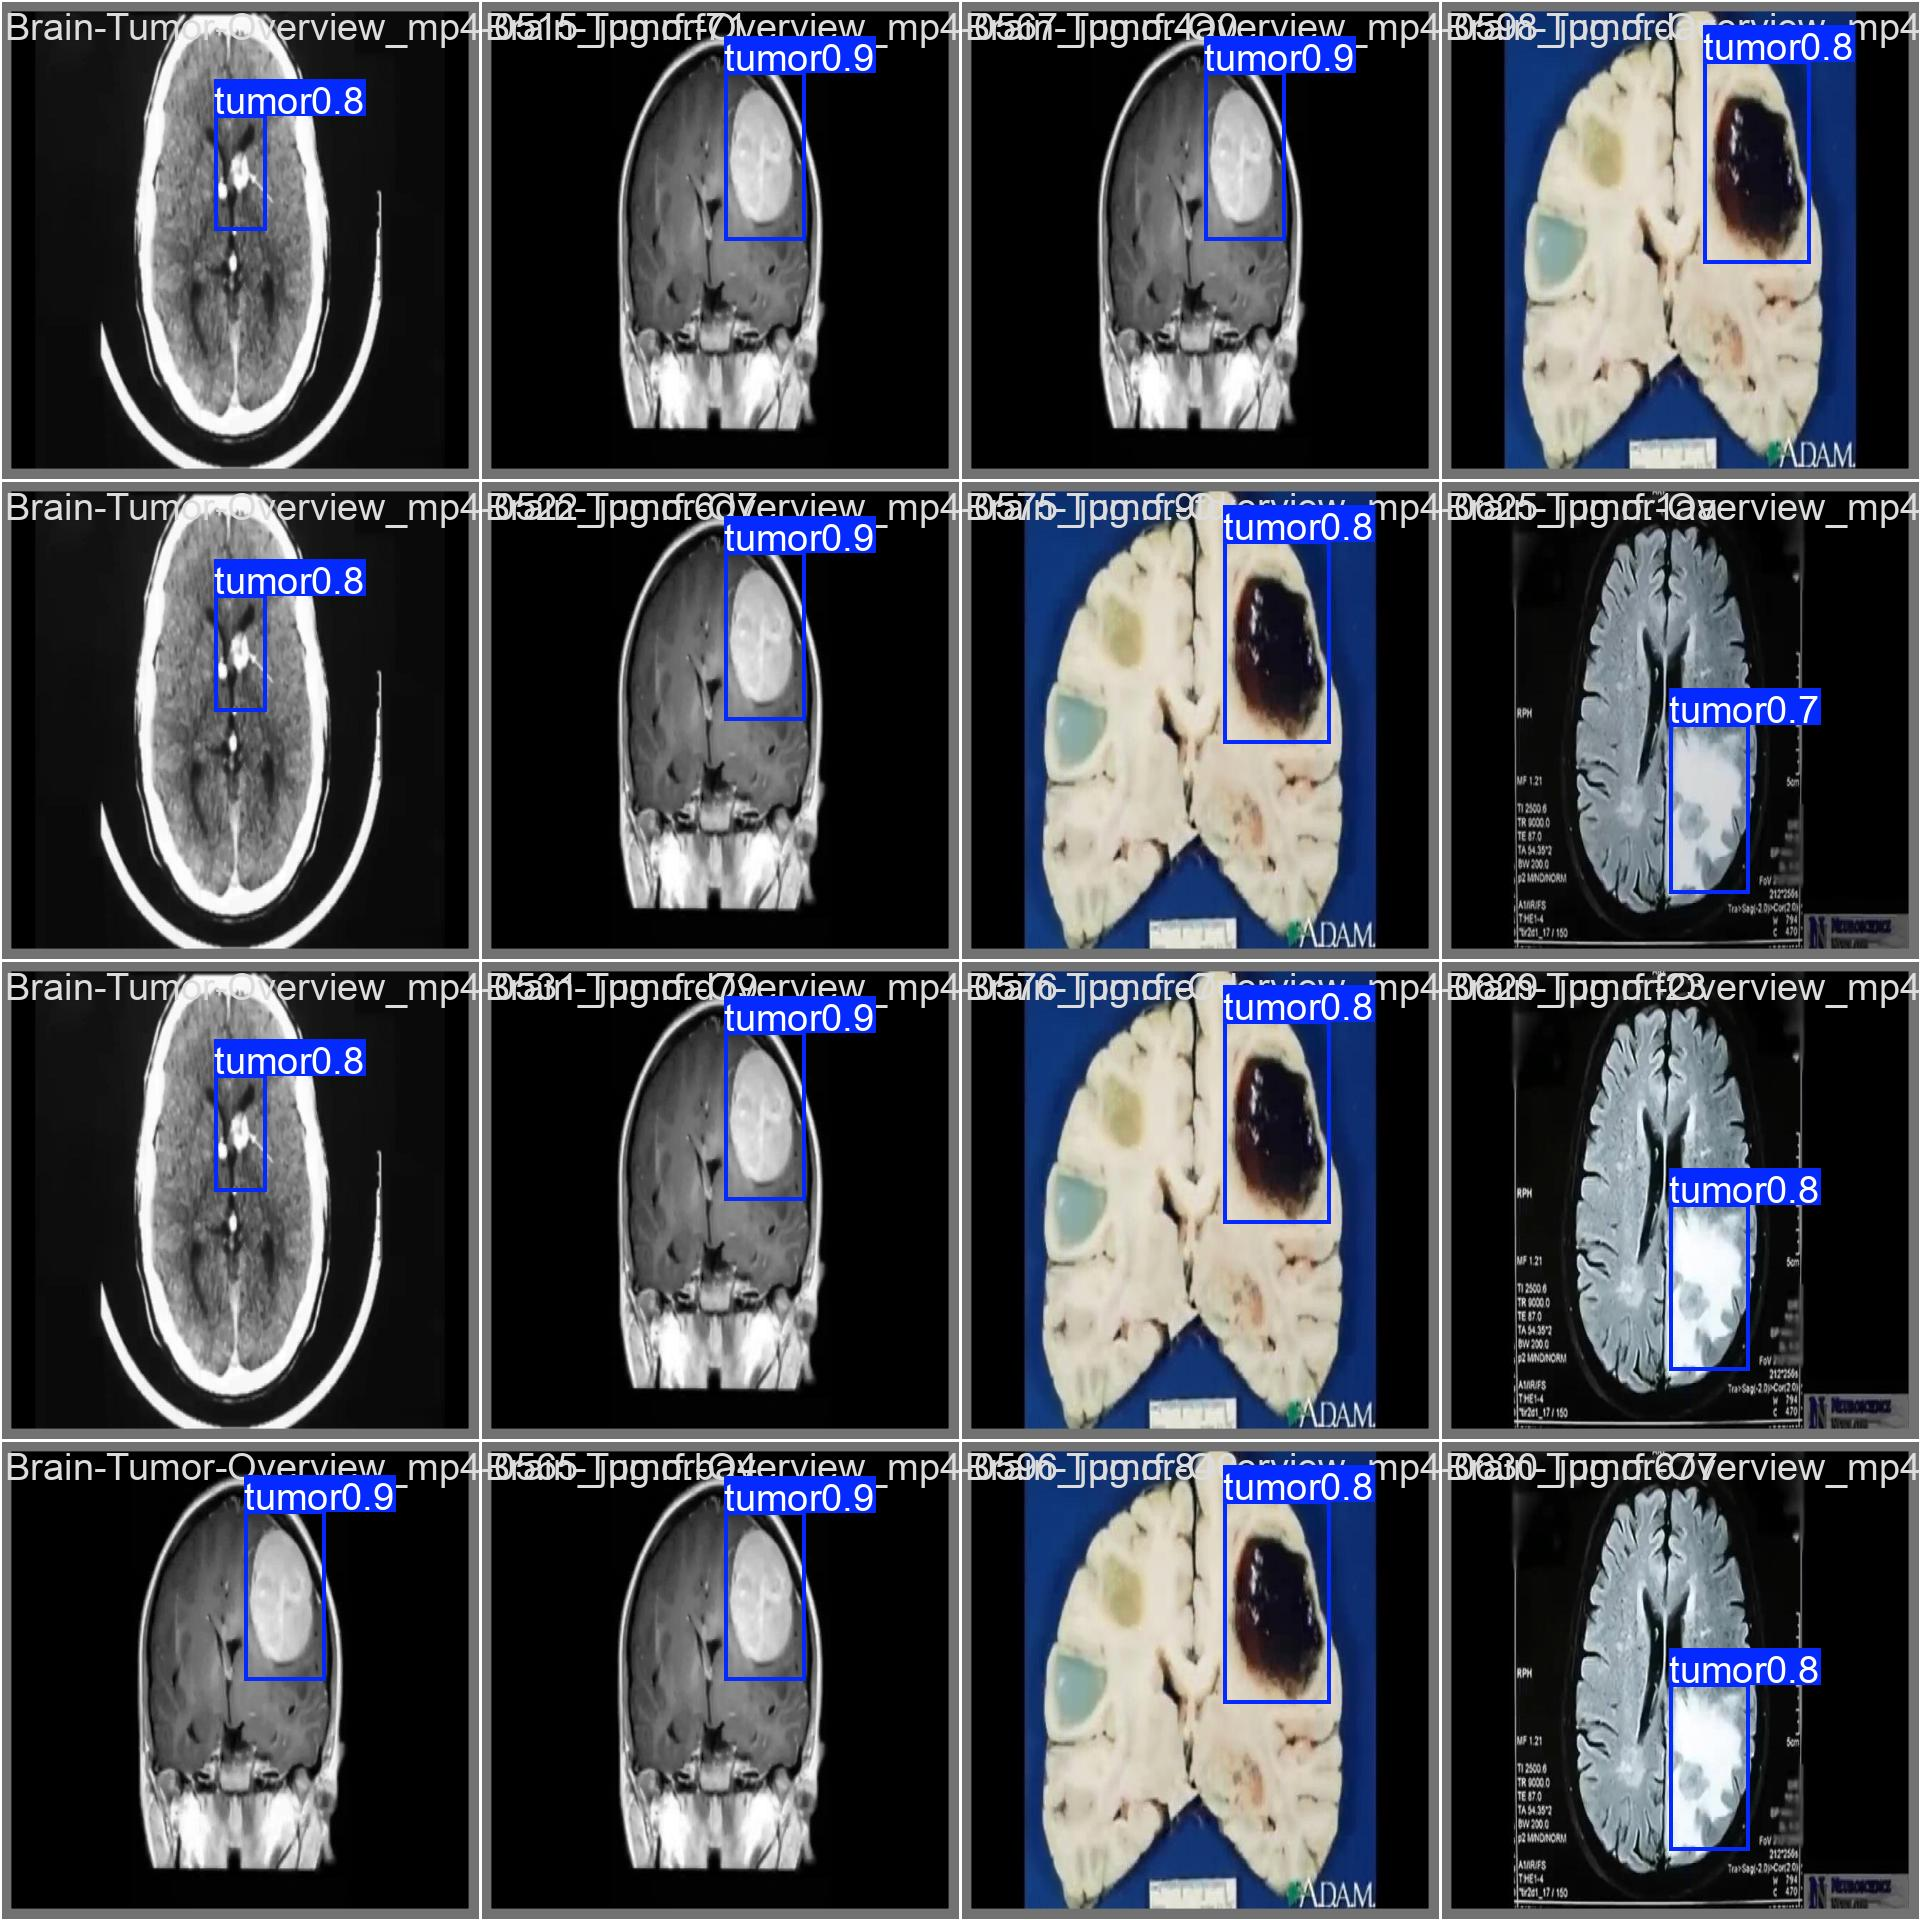

In [19]:
Image("/content/runs/detect/train-2/val_batch0_pred.jpg", width=800)
Image("/content/runs/detect/train-2/val_batch1_pred.jpg", width=800)
Image("/content/runs/detect/train-2/val_batch2_pred.jpg", width=800)